In [1]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

import os
os.listdir('/content/drive/MyDrive/Colab')

['breast_cancer_classification_dataset (1) (1).csv',
 'placement_predict_50k.csv',
 'placement_dataset.csv',
 'placement_predict_50k Dataset (1).csv',
 'age_insurance.csv',
 '2520030358 _Experiment 4.ipynb',
 'placement_predict_50k_adjusted.csv',
 'Experiment5_2520030358.ipynb',
 'simple_placement_dataset.csv',
 'WineQT.csv',
 'Experiment_4_2520030358.ipynb',
 'xgboost_lightgbm_shap_student_dataset.csv',
 'student_data.csv',
 'iris_dataset.csv']

In [3]:


import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab/placement_dataset.csv')


Dataset:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0    

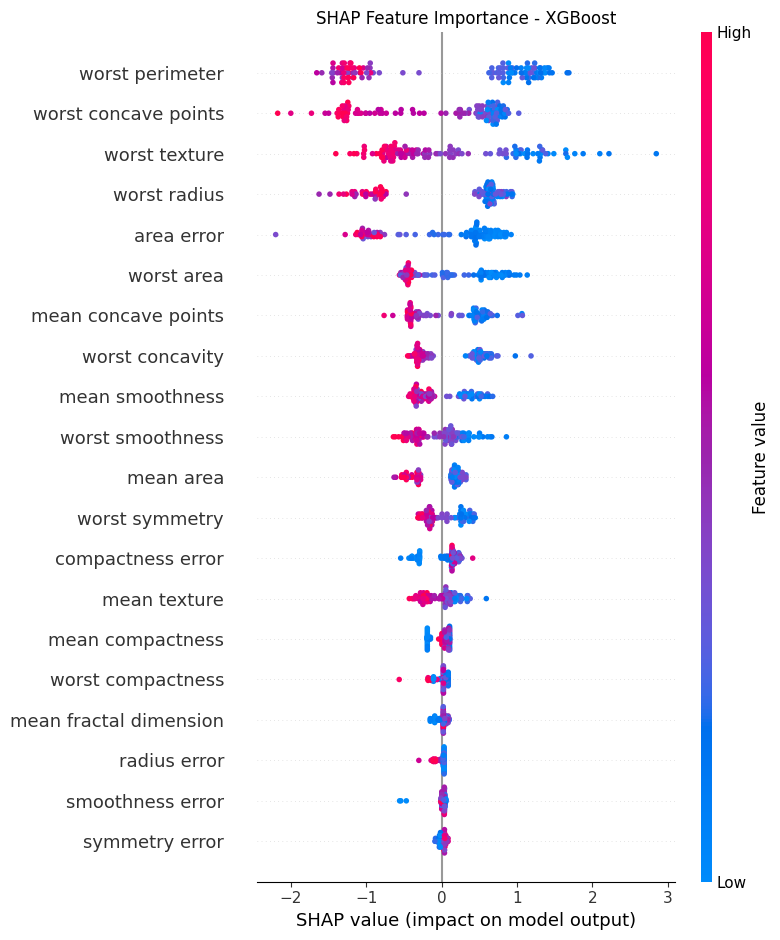

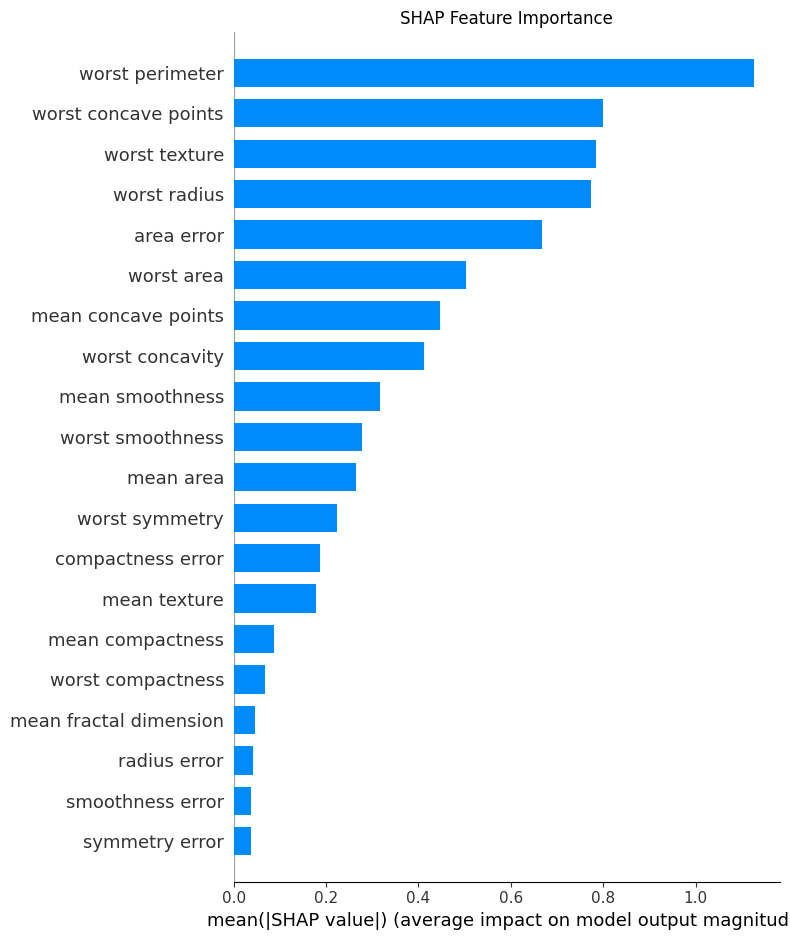

/usr/local/lib/python3.13/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


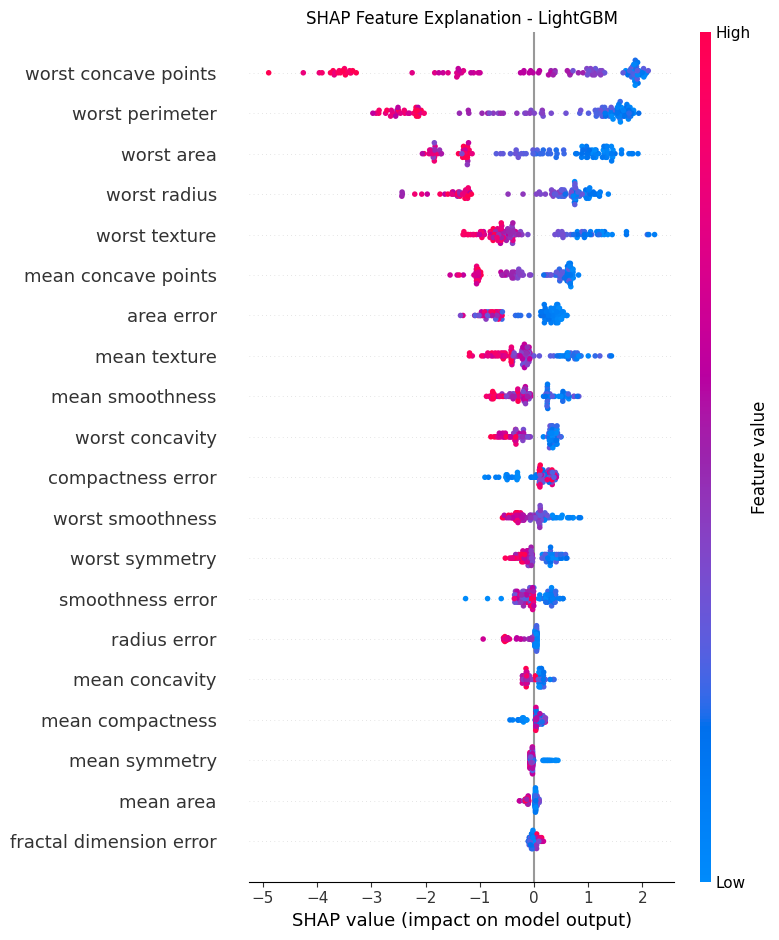


Project completed successfully!


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# ==========================================
# 1. LOAD DATASET
# ==========================================

data = pd.read_csv("/content/drive/MyDrive/Colab/breast_cancer_classification_dataset (1) (1).csv")

print("Dataset:")
print(data.head())

print("\nDataset Shape:")
print(data.shape)


# ==========================================
# 2. SEPARATE INPUT AND OUTPUT
# ==========================================

X = data.drop("target", axis=1)
y = data["target"]


# ==========================================
# 3. TRAIN-TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ==========================================
# 4. XGBOOST MODEL
# ==========================================

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("\n================================")
print("XGBOOST RESULTS")
print("================================")

print("Accuracy:", xgb_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))


# ==========================================
# 5. LIGHTGBM MODEL
# ==========================================

lgb_model = LGBMClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    verbosity=-1
)

lgb_model.fit(X_train, y_train)

lgb_pred = lgb_model.predict(X_test)

lgb_accuracy = accuracy_score(y_test, lgb_pred)

print("\n================================")
print("LIGHTGBM RESULTS")
print("================================")

print("Accuracy:", lgb_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, lgb_pred))


# ==========================================
# 6. MODEL COMPARISON
# ==========================================

print("\n================================")
print("MODEL COMPARISON")
print("================================")

print("XGBoost Accuracy :", xgb_accuracy)
print("LightGBM Accuracy:", lgb_accuracy)


# ==========================================
# 7. SHAP EXPLANATION FOR XGBOOST
# ==========================================

print("\nGenerating SHAP explanation...")

explainer_xgb = shap.TreeExplainer(xgb_model)

shap_values_xgb = explainer_xgb.shap_values(X_test)


# ==========================================
# 8. SHAP SUMMARY PLOT
# ==========================================

plt.figure()

shap.summary_plot(
    shap_values_xgb,
    X_test,
    show=False
)

plt.title("SHAP Feature Importance - XGBoost")

plt.tight_layout()

plt.show()


# ==========================================
# 9. SHAP BAR PLOT
# ==========================================

plt.figure()

shap.summary_plot(
    shap_values_xgb,
    X_test,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Importance")

plt.tight_layout()

plt.show()


# ==========================================
# 10. LIGHTGBM SHAP EXPLANATION
# ==========================================

explainer_lgb = shap.TreeExplainer(lgb_model)

shap_values_lgb = explainer_lgb.shap_values(X_test)

plt.figure()

shap.summary_plot(
    shap_values_lgb,
    X_test,
    show=False
)

plt.title("SHAP Feature Explanation - LightGBM")

plt.tight_layout()

plt.show()


print("\nProject completed successfully!")
